### 전처리

In [1]:
import pandas as pd
import numpy as np


review = pd.read_csv('review_all.csv')
member = pd.read_csv('member_info.csv')
product = pd.read_csv('product_info.csv')
product1 = pd.read_excel('product1.xlsx')
blog = pd.read_csv('oooo 블로그 체험단.csv')
influencer = pd.read_csv('oooo 인플루언서.csv')

# 리뉴얼 오더데이터로 전처리한 코드
renewall = pd.read_csv('renewal_order1.csv')
renewal2 = pd.read_csv('renewal_order2.csv')
renewal3 = pd.read_csv('renewal_order3.csv')
renewal4 = pd.read_csv('renewal_order4.csv')
renewal = pd.concat([renewall, renewal2, renewal3, renewal4], ignore_index=True)

# [전처리 1] order데이터 :주문자식별코드 생성 = (주문자ID O)주문자ID+주문자 주소/(주문자ID X) 주문자명+주문자 주소 
order_copy = renewal.copy()
order_copy['주문자식별코드'] = renewal['주문자ID'].fillna((renewal['주문자명'].fillna('') 
                                                + renewal['주문자 주소'].fillna('')).str.strip())

order_copy['우편식별코드'] = renewal['주문자ID'].fillna(
    (renewal['주문자명'].fillna('').astype(str) + renewal['주문자우편번호'].fillna('').astype(str)).str.strip())

# [전처리 2] member 데이터 : 이상치 아이디('3934758155@k') 제외한 데이터프레임 생성
member_copy = member.copy()
member_copy = member_copy[member_copy['아이디'] != '3934758155@k']

# [전처리 3] order데이터 : 최초재구매 컬럼 생성 > 주문자식별코드별 최초 주문일시 계산
first_orders = order_copy.groupby('주문자식별코드')['주문일시'].transform('min')
order_copy['최초재구매'] = order_copy['주문일시'] == first_orders
order_copy['최초재구매'] = order_copy['최초재구매'].map({True: '최초구매', False: '재구매'})

# [전처리 4] order데이터 : 회원/비회원 컬럼 생성
order_copy['회원여부'] = order_copy['주문자ID'].apply(lambda x: '회원' if pd.notnull(x) and x != '' else '비회원')

# [전처리 5] order데이터 : '주문일시' 컬럼을 datetime 형식으로 변환 > 년/월/일/시간 컬럼 생성
order_copy['주문일시'] = pd.to_datetime(order_copy['주문일시'], errors='coerce')
order_copy['년'] = order_copy['주문일시'].dt.year
order_copy['월'] = order_copy['주문일시'].dt.month
order_copy['일'] = order_copy['주문일시'].dt.day
order_copy['시간'] = order_copy['주문일시'].dt.hour
order_copy['주차'] = order_copy['주문일시'].dt.isocalendar().week
order_copy['요일'] = order_copy['주문일시'].dt.dayofweek

# [전처리 6] order데이터 : 환불 건 제외한 매출금액 생성
order_copy['매출금액'] = np.where(order_copy['실제 환불금액'] > 0, order_copy['총 결제금액'], order_copy['상품구매금액'])

# 무통장입금 제외
order_copy = order_copy[(order_copy['총 결제금액']>0)&(order_copy['실제 환불금액']==0)]
# order_copy['매출금액1'] = np.where((order_copy['총 결제금액'] > 0) & (order_copy['실제 환불금액'] == 0), order_copy['상품구매금액'] ,0)
# order_copy['수량1'] = np.where((order_copy['총 결제금액'] > 0) & (order_copy['실제 환불금액'] == 0), order_copy['수량'] ,0)

# [전처리 7] order데이터 : '[심명성님 개인결제창]' 이상치 제거한 행만 남기기
order_copy = order_copy[order_copy['주문상품명(기본)'] != '[심명성님 개인결제창]']
# order_None = order_copy[(order_copy['총 결제금액']>0)&(order_copy['실제 환불금액']==0)].groupby('주문상품명')[['상품구매금액']].sum().sort_values(by='상품구매금액',ascending=False)

In [2]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 윈도우 기본 한글 폰트 'Malgun Gothic'
plt.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False  # 마이너스(-) 깨짐 방지

### 첫구매 전환 관련 회원vs비회원 상품(년도별 top5상품)

In [22]:
# 1. 주문자식별코드별 첫 주문일 구하기
first_order_dates = order_copy.groupby('주문자식별코드')['주문일시'].min().reset_index()
first_order_dates.columns = ['주문자식별코드', '첫주문일시']

# 2. order_copy에 첫 주문 여부 표시
first_orders = pd.merge(order_copy, first_order_dates, on='주문자식별코드', how='left')
first_orders = first_orders[first_orders['주문일시'] == first_orders['첫주문일시']]

# 3. 년도별 회원/비회원 첫 구매 상품 집계
first_product_summary = (
    first_orders.groupby(['년', '회원여부', '주문상품명'])['주문번호']
    .count()
    .reset_index()
    .rename(columns={'주문번호': '구매건수'})
)

# 4. 각 년도+회원여부별 상위 n개 상품 (예: 상위 5개)
top_n = 5
top_products_by_year = (
    first_product_summary.sort_values(['년', '회원여부', '구매건수'], ascending=[True, True, False])
    .groupby(['년', '회원여부'])
    .head(top_n)
    .reset_index(drop=True)
)

# 년도별로 출력
years = sorted(top_products_by_year['년'].unique())

for year in years:
    print(f"\n📅 {year}년")
    display_df = top_products_by_year[top_products_by_year['년'] == year].copy()
    display_df = display_df.drop(columns='년').sort_values(['회원여부', '구매건수'], ascending=[True, False])
    display(display_df)



📅 2023년


,회원여부,주문상품명,구매건수
0,비회원,호안오닉스 카네스톤,2264
1,비회원,자마노 레브스톤 4mm,765
2,비회원,호안석 트레스톤,283
3,비회원,굿스톤 포르테스톤 세트,272
4,비회원,레브스톤 포르테스톤 세트 4mm,230
5,회원,호안오닉스 카네스톤,630
6,회원,자마노 레브스톤 4mm,180
7,회원,아이아게이트 디오스톤,106
8,회원,레브스톤 포르테스톤 세트 4mm,98
9,회원,호안석 트레스톤,86



📅 2024년


,회원여부,주문상품명,구매건수
10,비회원,호안오닉스 카네스톤,782
11,비회원,호안오닉스 팬텀골드,482
12,비회원,자마노 레브스톤 4mm,399
13,비회원,호안석 골드 플렌티스톤,328
14,비회원,쇼핑백,150
15,회원,호안오닉스 카네스톤,369
16,회원,호안오닉스 팬텀골드,317
17,회원,호안석 골드 플렌티스톤,209
18,회원,자마노 레브스톤 4mm,145
19,회원,쇼핑백,126



📅 2025년


,회원여부,주문상품명,구매건수
20,비회원,자마노 아가페스톤,235
21,비회원,팬텀골드 커플세트,150
22,비회원,호안오닉스 팬텀골드,125
23,비회원,아가페스톤 커플세트,64
24,비회원,자마노 레브스톤 4mm,59
25,회원,팬텀골드 커플세트,129
26,회원,자마노 아가페스톤,97
27,회원,호안오닉스 팬텀골드,60
28,회원,아가페스톤 커플세트,43
29,회원,자마노 레브스톤 4mm,30


### 신상품 효과분석

In [5]:
# 두 번째 행을 컬럼명으로 불러오기
product1 = pd.read_excel('product1.xlsx', sheet_name=0, header=1)

# 컬럼명 확인
product1.columns.tolist()

['상품등록일',
 '상품코드',
 '상품분류 번호',
 '상품명',
 '판매가',
 '옵션사용',
 '옵션입력',
 '장바구니수',
 '결제수',
 '진열상태',
 '상품번호',
 '판매상태']

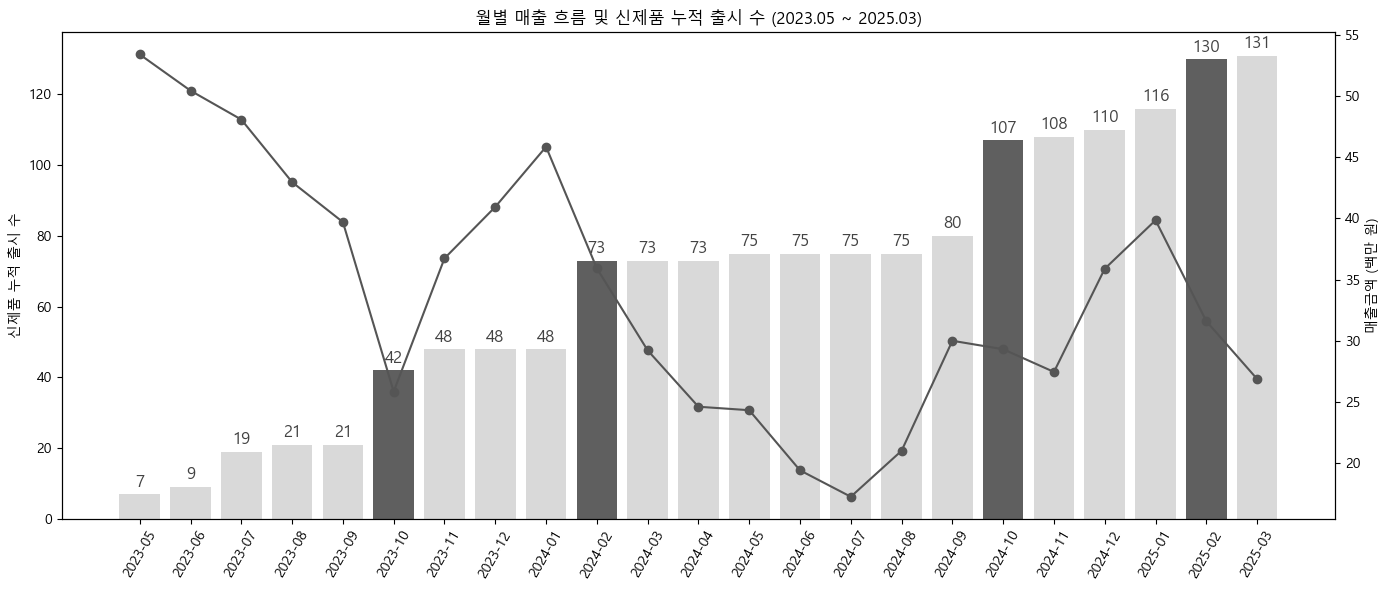

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. 매출 데이터 준비
order_copy['년월'] = order_copy['주문일시'].dt.to_period('M')
monthly_sales = order_copy.groupby('년월')['매출금액'].sum().reset_index()
monthly_sales['년월'] = monthly_sales['년월'].astype(str)
monthly_sales['매출금액'] = monthly_sales['매출금액'] / 1_000_000  # 백만원 단위로 변환

# 2. 신제품 데이터 준비
product1['상품등록일'] = pd.to_datetime(product1['상품등록일'])
product1 = product1[product1['상품등록일'] >= pd.to_datetime('2023-05-01')].copy()
product1['년월'] = product1['상품등록일'].dt.to_period('M')
monthly_new = product1.groupby('년월').size().reset_index(name='신제품수')
monthly_new = monthly_new.sort_values('년월')
monthly_new['누적신제품수'] = monthly_new['신제품수'].cumsum()
monthly_new['년월'] = monthly_new['년월'].astype(str)

# 3. 전체 기간 생성 및 병합
all_months = pd.date_range(start='2023-05', end='2025-03', freq='MS').to_period('M').astype(str)
all_months_df = pd.DataFrame({'년월': all_months})

combined = all_months_df.merge(monthly_sales, on='년월', how='left')
combined = combined.merge(monthly_new[['년월', '누적신제품수']], on='년월', how='left')
combined['매출금액'] = combined['매출금액'].fillna(0)
combined['누적신제품수'] = combined['누적신제품수'].ffill().fillna(0)

강조_출시월 = ['2023-10', '2024-02', '2024-10', '2025-02']
bar_colors = ['#434343' if ym in 강조_출시월 else '#D3D3D3' for ym in combined['년월']]


# 4. 시각화
fig, ax1 = plt.subplots(figsize=(14, 6))

# 막대: 신제품 누적 출시 수
bar_colors = ['#434343' if ym in 강조_출시월 else '#D3D3D3' for ym in combined['년월']]
bars = ax1.bar(combined['년월'], combined['누적신제품수'], color=bar_colors, alpha=0.85, zorder=1)
ax1.set_ylabel('신제품 누적 출시 수', color='black')
ax1.tick_params(axis='y', labelcolor='black')

# 막대 위 숫자
for bar in bars:
    height = int(bar.get_height())
    if height > 0:
        ax1.text(bar.get_x() + bar.get_width()/2, height + 1, str(height), ha='center', va='bottom', fontsize=12, color='#434343')

# 선: 매출
ax2 = ax1.twinx()
ax2.plot(combined['년월'], combined['매출금액'], marker='o', color='#555555', zorder=3)
ax2.set_ylabel('매출금액 (백만 원)', color='black')
ax2.tick_params(axis='y', labelcolor='black')
ax1.tick_params(axis='x', rotation=60)
ax1.grid(False)  # 격자 제거

plt.title('월별 매출 흐름 및 신제품 누적 출시 수 (2023.05 ~ 2025.03)')
fig.tight_layout()
plt.show()


In [15]:
# 상품 등록월 전체로 확대
product1['상품등록일'] = pd.to_datetime(product1['상품등록일'])
product1['등록월'] = product1['상품등록일'].dt.to_period('M')

# 모든 신제품 목록과 출시월 설정
product_all = product1[['상품명', '등록월']].copy()
product_all.rename(columns={'등록월': '출시월'}, inplace=True)

# order에 등록월 매핑
신제품_전체_매핑 = pd.merge(
    order_copy[order_copy['주문상품명'].isin(product_all['상품명'])],
    product_all,
    left_on='주문상품명',
    right_on='상품명',
    how='inner'
)

# 년월 및 시점 계산
신제품_전체_매핑['년월'] = 신제품_전체_매핑['주문일시'].dt.to_period('M')
신제품_전체_매핑['시점'] = (신제품_전체_매핑['년월'] - 신제품_전체_매핑['출시월']).apply(lambda x: x.n)

# 전체 매출 집계
order_copy['년월'] = order_copy['주문일시'].dt.to_period('M')
전체_매출 = order_copy.groupby('년월')['매출금액'].sum().reset_index(name='전체매출')

# 신제품 출시월 기준 매출 집계
신제품_출시별_비중 = (
    신제품_전체_매핑
    .groupby(['출시월', '년월'])['매출금액']
    .sum()
    .reset_index(name='신제품매출')
)

# 전체 매출 병합 후 비중 계산
신제품_출시별_비중 = pd.merge(신제품_출시별_비중, 전체_매출, on='년월', how='left')
신제품_출시별_비중['비중'] = (신제품_출시별_비중['신제품매출'] / 신제품_출시별_비중['전체매출']) * 100

# 피벗으로 스택형용 데이터 변환
stack_df = 신제품_출시별_비중.pivot(index='년월', columns='출시월', values='비중').fillna(0).sort_index()

# 시각화 재작성: 범례 축소 + 지정된 출시월만 선 표시
지정_출시월 = [pd.Period('2023-10'), pd.Period('2024-02'), pd.Period('2024-10')]

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
# 기존 상품 매출 비중 추가: 전체 - 출시월별 비중 합계
stack_df_copy = stack_df.copy()
stack_df_copy['기타(기존상품)'] = 100 - stack_df_copy.sum(axis=1)

# 기존 구성과 동일하게 추적 출시월 + 기타 출시월 + 기존상품 구성
stack_df_기타 = stack_df_copy.drop(columns=지정_출시월, errors='ignore')
stack_df_주요 = stack_df_copy[지정_출시월].copy()
stack_df_기타['기타출시월'] = stack_df_기타.drop(columns='기타(기존상품)').sum(axis=1)
stack_df_최종_보완 = pd.concat([stack_df_주요, stack_df_기타[['기타출시월', '기타(기존상품)']]], axis=1)

# '호안닉스 리치스톤' 상품 제외
제외상품 = ['호안닉스 리치스톤', '헤마타이트 릴렉스톤']
신제품_전체_매핑_필터 = 신제품_전체_매핑[~신제품_전체_매핑['주문상품명'].isin(제외상품)]

# 재계산: 출시월, 년월 기준으로 신제품 매출 집계
신제품_출시별_비중_필터 = (
    신제품_전체_매핑_필터
    .groupby(['출시월', '년월'])['매출금액']
    .sum()
    .reset_index(name='신제품매출')
)

# 전체 매출 병합 후 비중 계산
신제품_출시별_비중_필터 = pd.merge(신제품_출시별_비중_필터, 전체_매출, on='년월', how='left')
신제품_출시별_비중_필터['비중'] = (신제품_출시별_비중_필터['신제품매출'] / 신제품_출시별_비중_필터['전체매출']) * 100

# 피벗 테이블로 변환
stack_df_필터 = 신제품_출시별_비중_필터.pivot(index='년월', columns='출시월', values='비중').fillna(0).sort_index()

# 시각화 재작성: 범례 축소 + 지정된 출시월만 선 표시
지정_출시월 = [pd.Period('2023-10'), pd.Period('2024-02'), pd.Period('2024-10')]

# 다시 지정 출시월만 추적
stack_df_기타_필터 = stack_df_필터.drop(columns=지정_출시월, errors='ignore')
stack_df_주요_필터 = stack_df_필터[지정_출시월].copy()
stack_df_기타_필터['기타출시월'] = stack_df_기타_필터.sum(axis=1)

# 기존상품 비중 계산
stack_df_최종_필터 = pd.concat([stack_df_주요_필터, stack_df_기타_필터[['기타출시월']]], axis=1)
stack_df_최종_필터['기존상품'] = 100 - stack_df_최종_필터.sum(axis=1)

In [17]:
# 전체 매출 선그래프를 먼저 그리고, 비율 기준으로 정규화 (왼쪽 y축과 맞추기 위해)
전체_매출_plot = 전체_매출.set_index('년월').reindex(stack_df_최종_필터.index).fillna(0)
전체_매출_정규화 = 전체_매출_plot['전체매출'] / 전체_매출_plot['전체매출'].max() * 100

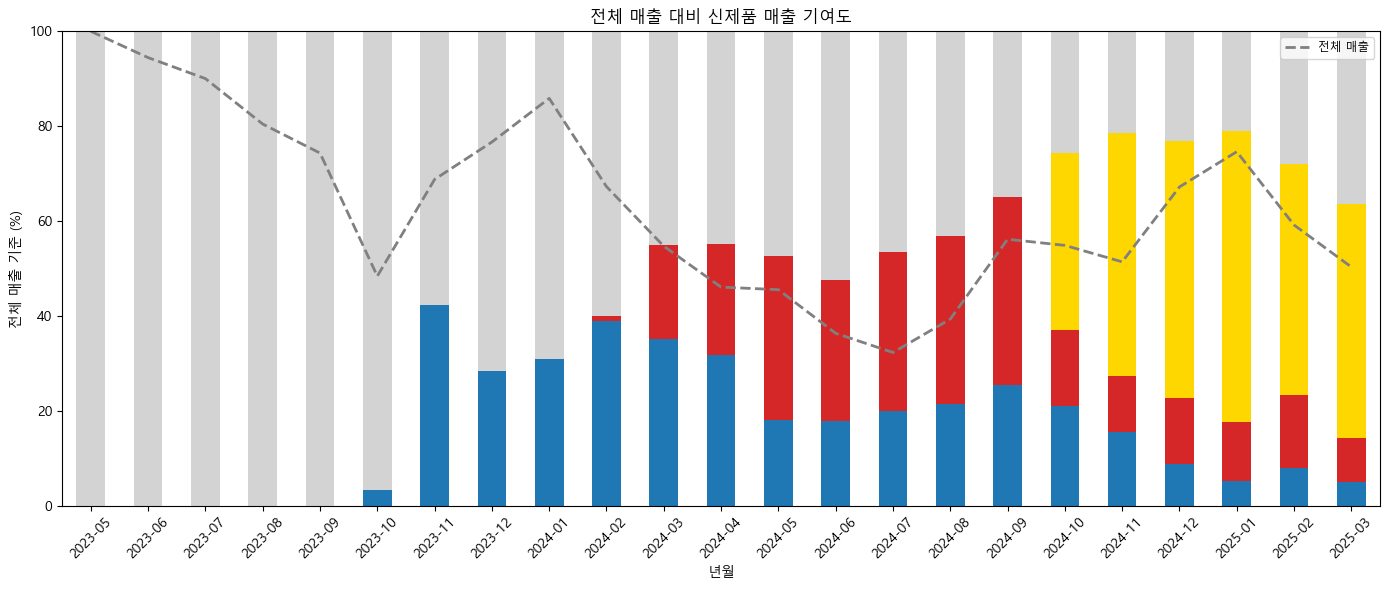

In [19]:
# 색상 매핑 (지정 출시월 3개 + 기타 출시월 + 기존상품)
색상_보완 = ['#1F77B4', '#D62728', '#FFD700', '#D3D3D3', '#D3D3D3']  # blue, green, orange, light gray, dark gray
legend_labels_보완 = ['2023-10', '2024-02', '2024-10', '기타 상품']

# 기준이 되는 출시월 (빨간 점선으로 표시하고 싶은 기준 월)
기준_출시월 = ['2023-10', '2024-02', '2024-10', '2025-02']
기준_출시월_periods = [pd.Period(m) for m in 기준_출시월]

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

fig, ax1 = plt.subplots(figsize=(14, 6))

# 선 그래프 (전체 매출)
ax1.plot(
    전체_매출_plot.index.astype(str),
    전체_매출_정규화,
    color='gray',
    linewidth=2,
    linestyle='--'
)

# 막대그래프 (색상은 그대로, 범례는 False)
stack_df_최종_필터.plot(
    kind='bar',
    stacked=True,
    ax=ax1,
    color=색상_보완,
    legend=False
)

# 범례 핸들: 점선만
custom_legend_handles_단일 = [
    Line2D([0], [0], color='gray', linestyle='--', linewidth=2, label='전체 매출')
]

ax1.legend(
    handles=custom_legend_handles_단일,
    loc='upper right',
    fontsize=8.5
)

# 나머지 설정
ax1.set_ylim(0, 100)
ax1.set_ylabel('전체 매출 기준 (%)')
ax1.set_xlabel('년월')
ax1.set_title("전체 매출 대비 신제품 매출 기여도")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### 스테디셀러 발굴

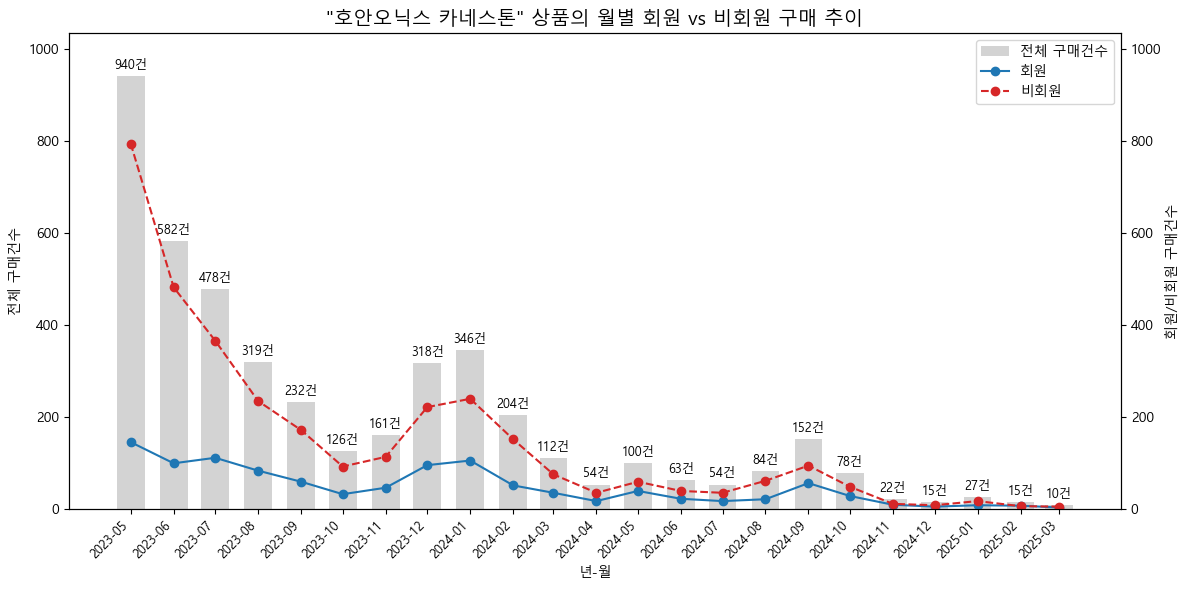

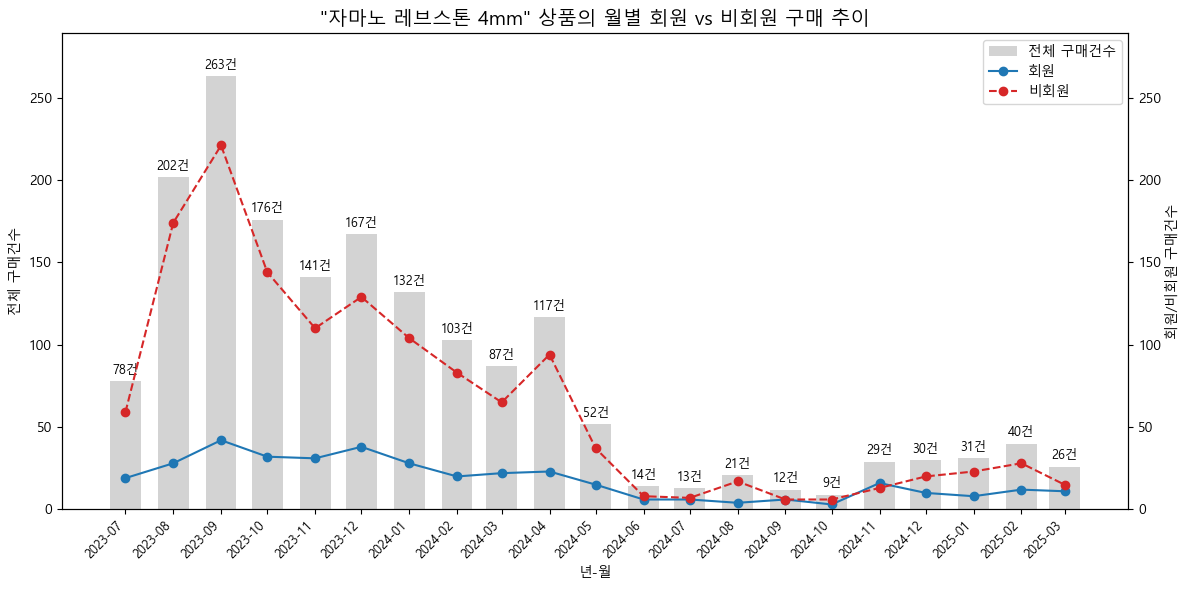

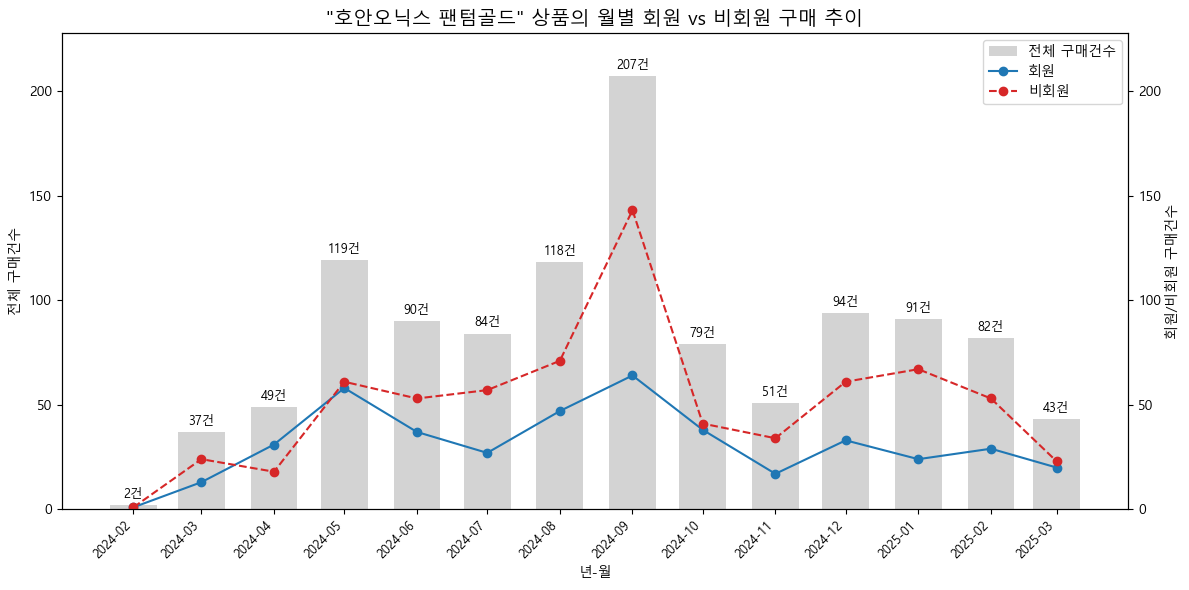

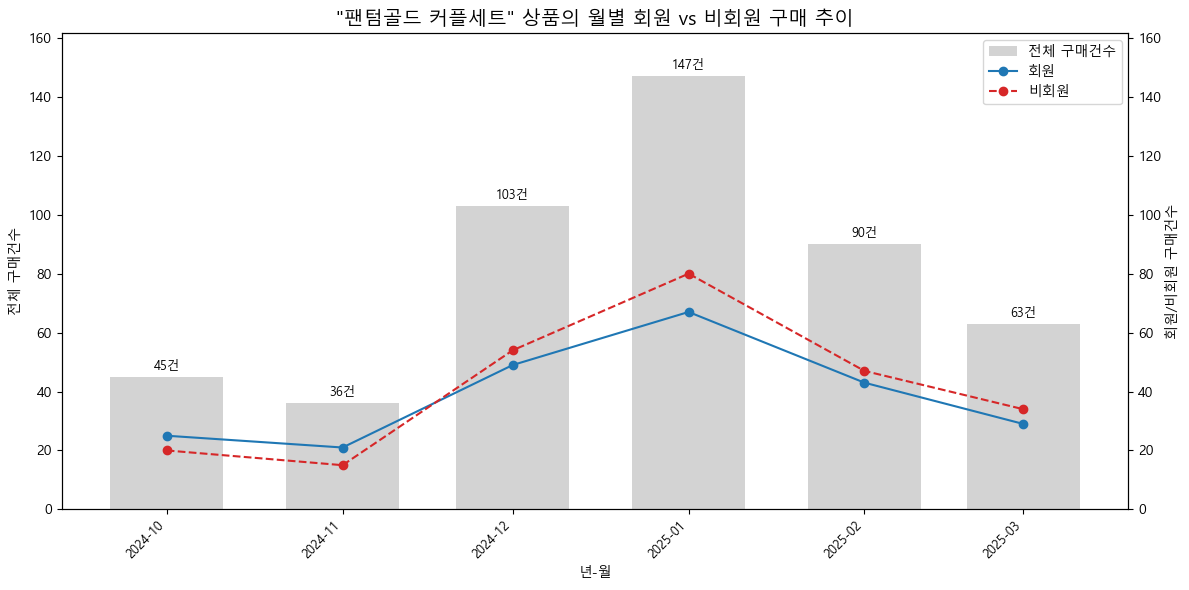

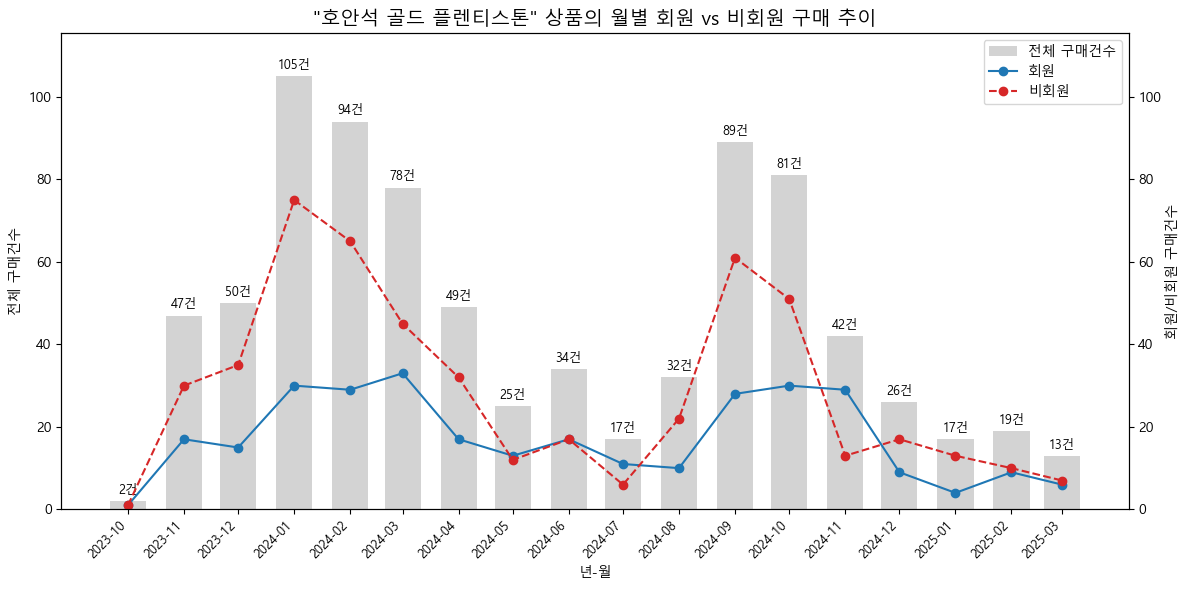

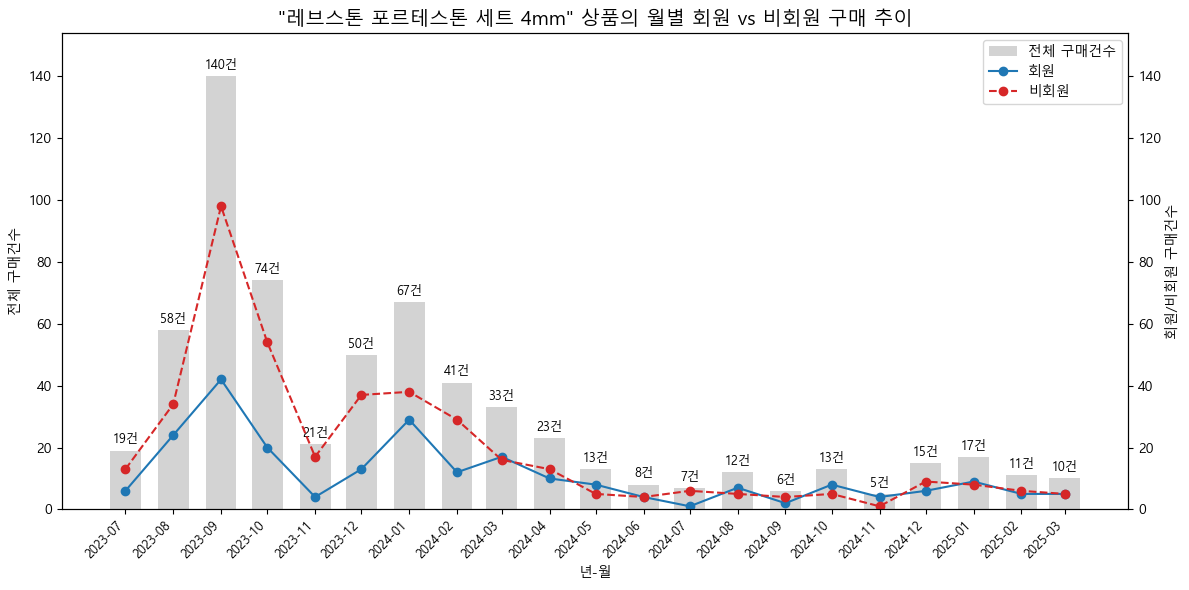

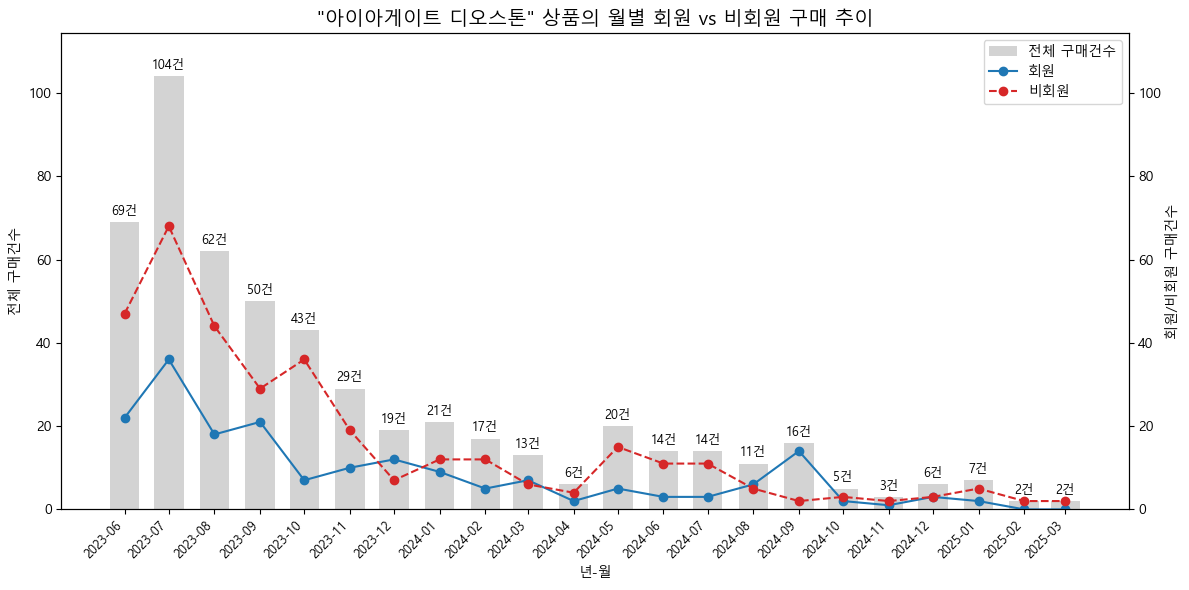

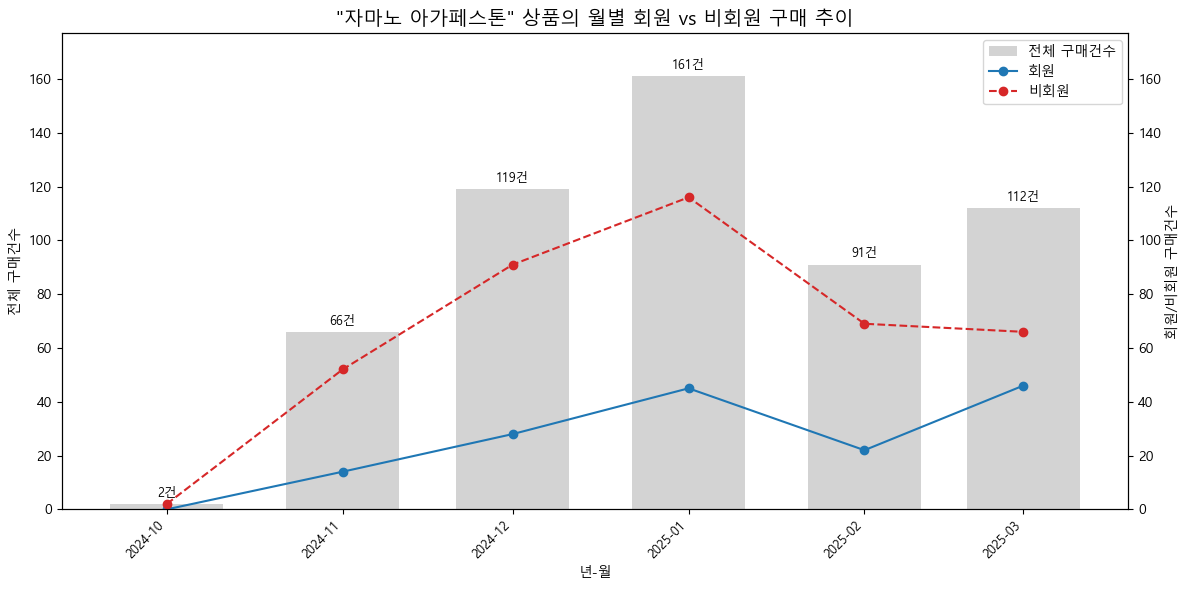

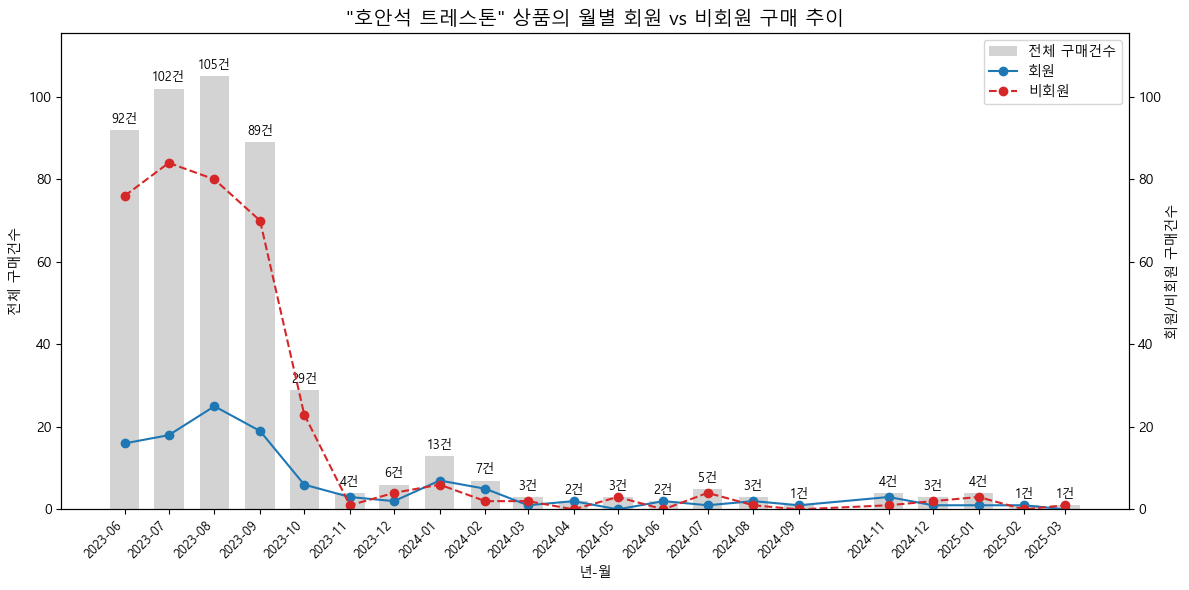

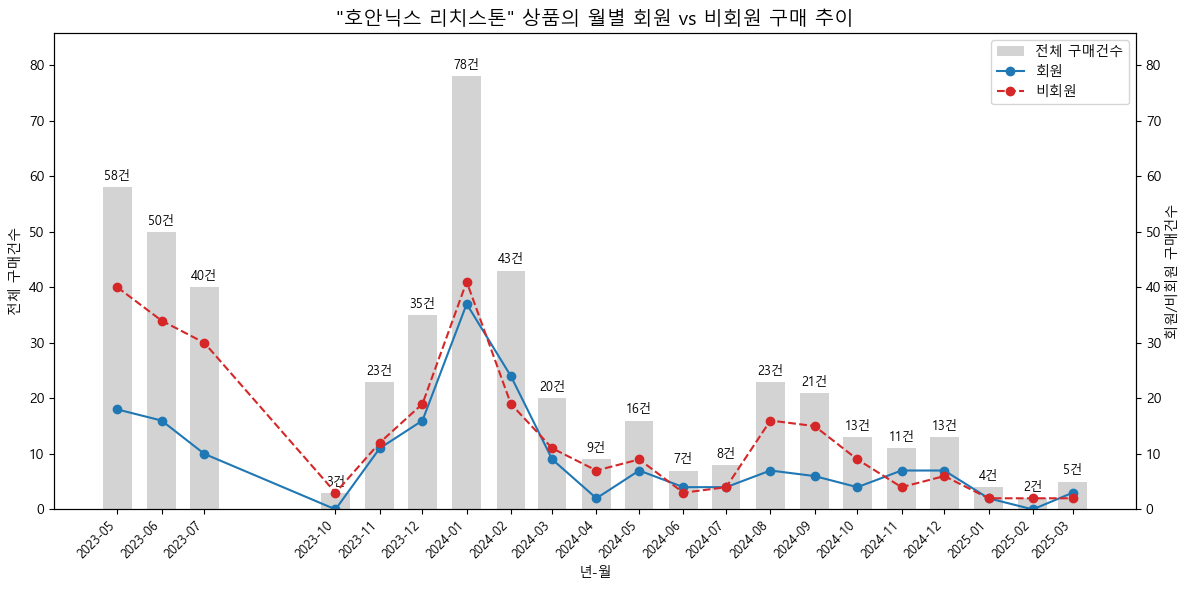

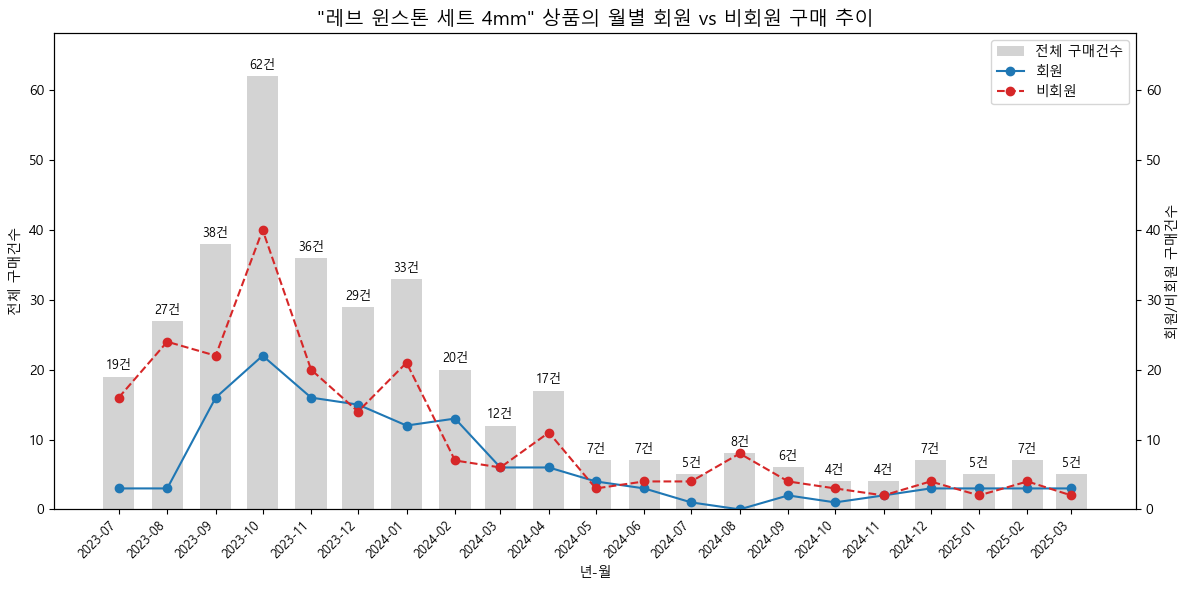

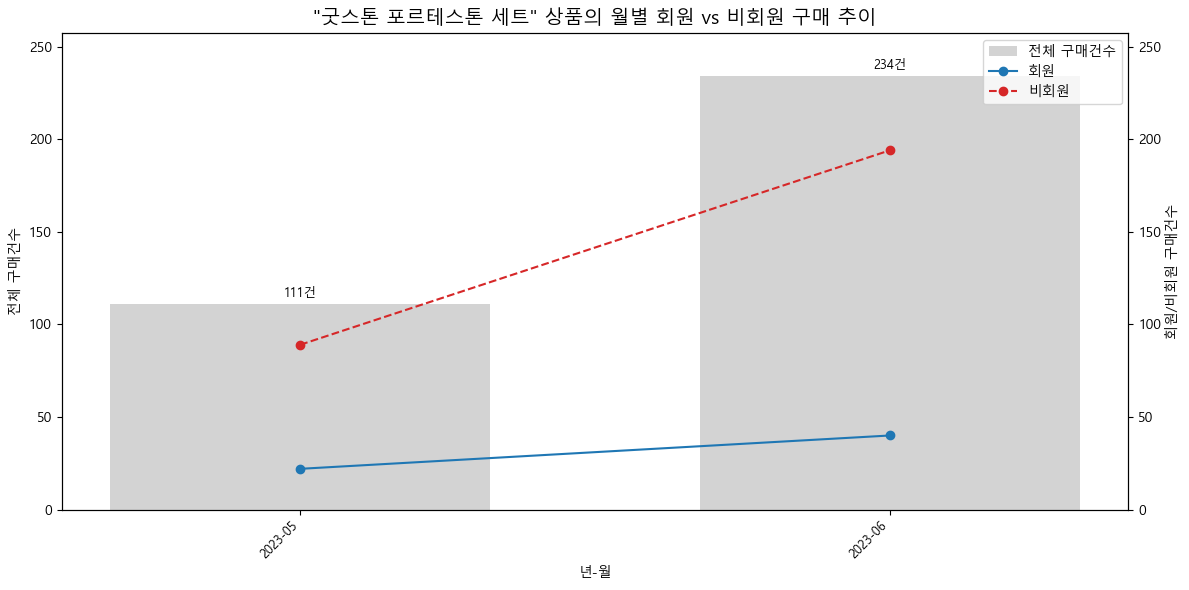

In [20]:
import pandas as pd
import matplotlib.pyplot as plt

# 스테디셀러 리스트 정의
steady_products = ['호안오닉스 카네스톤', '자마노 레브스톤 4mm', '호안오닉스 팬텀골드', '팬텀골드 커플세트', '호안석 골드 플렌티스톤', '레브스톤 포르테스톤 세트 4mm', '아이아게이트 디오스톤', '자마노 아가페스톤', '호안석 트레스톤', '호안닉스 리치스톤', '레브 윈스톤 세트 4mm', '굿스톤 포르테스톤 세트']

# 날짜 처리
order_copy['주문일시'] = pd.to_datetime(order_copy['주문일시'])
order_copy['년'] = order_copy['주문일시'].dt.year
order_copy['월'] = order_copy['주문일시'].dt.month
order_copy['년-월'] = order_copy['주문일시'].dt.to_period('M').astype(str)

# 월별 상품별 회원/비회원 구매건수 집계
grouped = order_copy.groupby(['주문상품명', '년-월', '회원여부']).size().reset_index(name='구매건수')

# 각 상품별 그래프 출력
for target_product in steady_products:
    df_line = grouped[grouped['주문상품명'] == target_product]

    # 피벗: '년-월'을 인덱스로 회원/비회원 나누기
    pivot = df_line.pivot(index='년-월', columns='회원여부', values='구매건수').fillna(0)
    pivot['전체'] = pivot.sum(axis=1)

    # x축 정렬용 datetime 처리
    pivot.index = pd.to_datetime(pivot.index)
    pivot = pivot.sort_index()

    # y축 최대값 동기화를 위한 최대값 계산
    y_max = max(pivot['전체'].max(), pivot.get('회원', pd.Series([0])).max(), pivot.get('비회원', pd.Series([0])).max()) * 1.1

    # 그래프
    fig, ax1 = plt.subplots(figsize=(12, 6))
    bars = ax1.bar(pivot.index, pivot['전체'], color='lightgray', label='전체 구매건수', width=20)
    ax1.set_xlabel('년-월')
    ax1.set_ylabel('전체 구매건수', color='black')
    ax1.tick_params(axis='y', labelcolor='black')
    ax1.set_ylim(0, y_max)

    # x축 라벨 포맷팅
    ax1.set_xticks(pivot.index)
    ax1.set_xticklabels(pivot.index.strftime('%Y-%m'), rotation=45, ha='right', fontsize=9)

    # 막대 위 텍스트
    ax1.bar_label(bars, labels=[f'{int(val)}건' for val in pivot['전체']], padding=3, fontsize=9, color='black')

    # 이중축: 회원/비회원 선그래프
    ax2 = ax1.twinx()
    if '회원' in pivot.columns:
        ax2.plot(pivot.index, pivot['회원'], color='#1F77B4', marker='o', label='회원')
    if '비회원' in pivot.columns:
        ax2.plot(pivot.index, pivot['비회원'], color='#D62728', marker='o', linestyle='--', label='비회원')

    ax2.set_ylabel('회원/비회원 구매건수', color='black')
    ax2.tick_params(axis='y', labelcolor='black')
    ax2.set_ylim(0, y_max)

    # 범례
    lines_1, labels_1 = ax1.get_legend_handles_labels()
    lines_2, labels_2 = ax2.get_legend_handles_labels()
    ax2.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper right')
    
    # 제목
    plt.title(f'"{target_product}" 상품의 월별 회원 vs 비회원 구매 추이', fontsize=14)
    fig.tight_layout()
    plt.show()
